In [59]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [60]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

In [74]:
%load_ext autoreload
%autoreload 2

### Query examples from Freesound

In [61]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [62]:
FREESOUND_API_KEY = os.getenv('FREESOUND_API_KEY')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [63]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [64]:
# Query for THIS RUN
query = "electric fan"
filt = None
num_results = 20

In [18]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = query_freesound(
        query=query,
        filter=filt,
        client=client,
        fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
        num_results=num_results,
)


print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
subdir_path = AUDIO_DIR + query.replace(" ", "-")
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, subdir_path)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, subdir_path)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "query": query,
    "subdir_path": subdir_path
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 563606
[2/20] Downloading sound ID 719800
[3/20] Downloading sound ID 55855
[4/20] Downloading sound ID 55854
[5/20] Downloading sound ID 783837
[6/20] Downloading sound ID 152533
[7/20] Downloading sound ID 650593
[8/20] Downloading sound ID 246168
[9/20] Downloading sound ID 558777
[10/20] Downloading sound ID 370162
[11/20] Downloading sound ID 99221
[12/20] Downloading sound ID 529757
[13/20] Downloading sound ID 35382
[14/20] Downloading sound ID 819061
[15/20] Downloading sound ID 641009
[16/20] Downloading sound ID 324665
[17/20] Downloading sound ID 554238
[18/20] Downloading sound ID 13278
[19/20] Downloading sound ID 244637
[20/20] Downloading sound ID 429713
Saved metadata CSV: ../data/meta/dataset_2026-05-06_16-36-55.csv
Saved query log JSON: ../data/meta/dataset_2026-05-06_16-36-55.json


In [65]:
dir(sounds[0])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'as_dict',
 'client',
 'get_analysis',
 'get_analysis_frames',
 'get_comments',
 'get_similar',
 'id',
 'json_dict',
 'license',
 'name',
 'previews',
 'retrieve',
 'retrieve_preview',
 'tags',
 'username']

In [66]:
!ls ../data/meta

dataset_2026-01-18_19-30-57.csv   dataset_2026-03-18_18-36-36.json
dataset_2026-01-18_19-30-57.json  dataset_2026-04-30_17-46-52.csv
dataset_2026-03-18_18-32-10.csv   dataset_2026-04-30_17-46-52.json
dataset_2026-03-18_18-32-10.json  dataset_2026-05-01_13-19-37.csv
dataset_2026-03-18_18-35-35.csv   dataset_2026-05-01_13-19-37.json
dataset_2026-03-18_18-35-35.json  dataset_2026-05-06_16-36-55.csv
dataset_2026-03-18_18-36-36.csv   dataset_2026-05-06_16-36-55.json


In [70]:
delete_dataset_with_gc(META_DIR + "dataset_2026-03-18_18-35-35.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-03-18_18-35-35.csv
Deleted query file: /workspace/data/meta/dataset_2026-03-18_18-35-35.json

GC summary:
  Kept audio files: 120
  Deleted audio files: 0


In [67]:
os.environ.get("FREESOUND_API_KEY")

'OplO8pCxAvTOTHXX81X4u7vFlzSbiz7IEwl2CrzJ'

### Show downloaded audio

In [21]:
!ls -lt ../data/audio | head -20

total 11576
-rw-r--r-- 1 root root  82323 May  6 16:36 429713_7872621-hq.ogg
-rw-r--r-- 1 root root  81505 May  6 16:36 244637_4478454-hq.ogg
-rw-r--r-- 1 root root  42265 May  6 16:36 13278_32468-hq.ogg
-rw-r--r-- 1 root root  10173 May  6 16:36 554238_6754542-hq.ogg
-rw-r--r-- 1 root root 102961 May  6 16:36 324665_5583936-hq.ogg
-rw-r--r-- 1 root root  97612 May  6 16:36 641009_13325778-hq.ogg
-rw-r--r-- 1 root root  46477 May  6 16:36 819061_16849877-hq.ogg
-rw-r--r-- 1 root root 123238 May  6 16:36 35382_95609-hq.ogg
-rw-r--r-- 1 root root  44846 May  6 16:36 529757_4473224-hq.ogg
-rw-r--r-- 1 root root  66457 May  6 16:36 99221_1669104-hq.ogg
-rw-r--r-- 1 root root  17719 May  6 16:36 370162_5048136-hq.ogg
-rw-r--r-- 1 root root  87144 May  6 16:36 558777_2397507-hq.ogg
-rw-r--r-- 1 root root 173827 May  6 16:36 246168_3426876-hq.ogg
-rw-r--r-- 1 root root  77158 May  6 16:36 650593_7965922-hq.ogg
-rw-r--r-- 1 root root 103996 May  6 16:36 152533_2289019-hq.ogg
-rw-r--r-- 1 root 

In [39]:
# select a file manually
filename = "66113_877451-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/66113_877451-hq.ogg'

In [68]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/389672_7158173-hq.ogg'

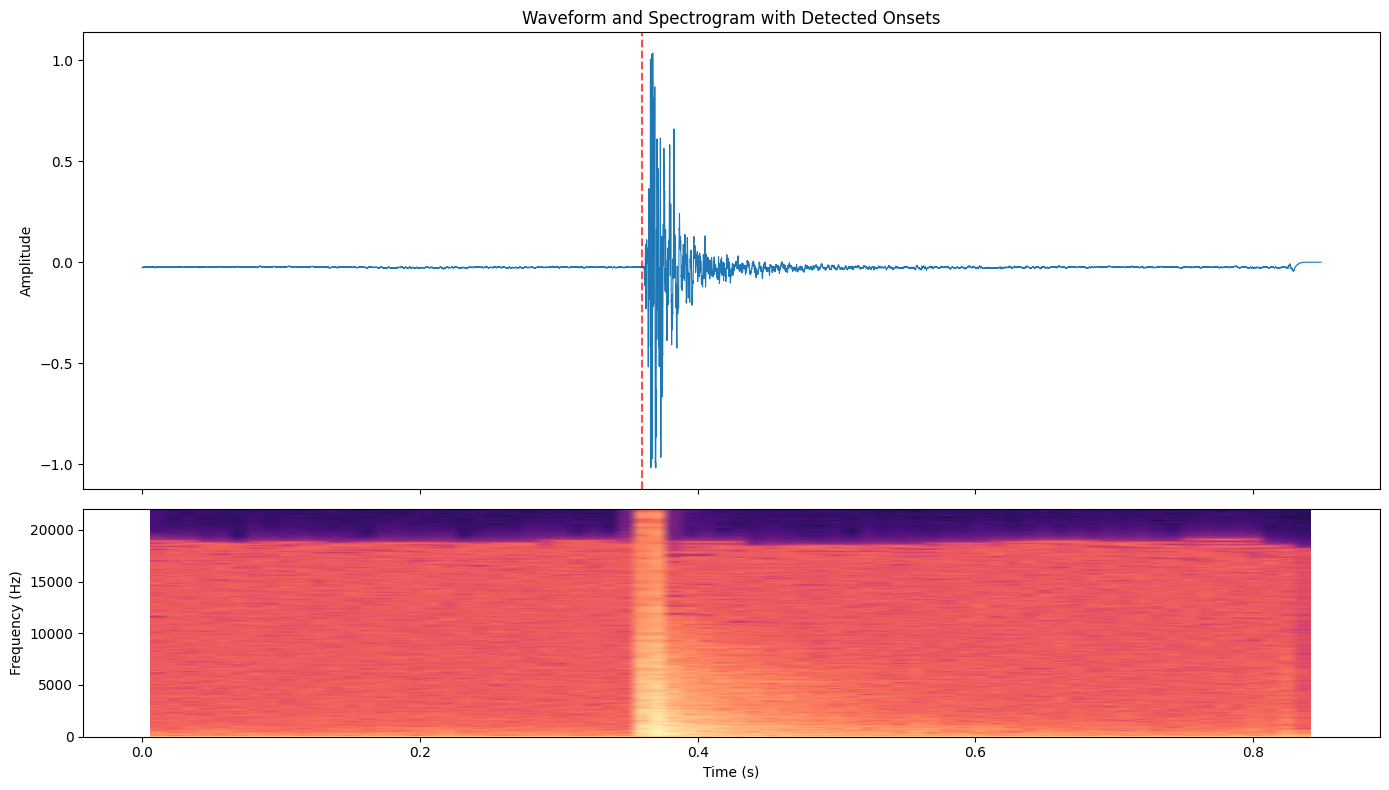

In [40]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)

In [75]:
import os
import glob
import json
import pandas as pd
from IPython.display import display, Audio

def _build_query_map(meta_dir):
    """Internal helper to map query strings to sets of unique Freesound IDs."""
    query_to_ids = {}
    global_unique_ids = set()
    
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        json_path = csv_path.rsplit(".", 1)[0] + ".json"
        
        # Fallback to filename
        query_str = os.path.basename(csv_path) 
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
                    
                    if "queries" in data and isinstance(data["queries"], list):
                        # NORMALIZATION 1: Strip whitespace from every query
                        q_list = [q.get("query", "").strip() for q in data["queries"]]
                        query_str = " + ".join(filter(None, q_list)) 
            except Exception:
                pass
                
        df = pd.read_csv(csv_path)
        if "sound_id" in df.columns:
            # NORMALIZATION 2: Use lowercase keys for internal storage
            lookup_key = query_str.lower()
            
            if lookup_key not in query_to_ids:
                # We store the 'display_name' so the table still looks nice
                query_to_ids[lookup_key] = {"display_name": query_str, "ids": set()}
            
            unique_in_csv = df["sound_id"].unique()
            query_to_ids[lookup_key]["ids"].update(unique_in_csv)
            global_unique_ids.update(unique_in_csv)
            
    return query_to_ids, global_unique_ids

# ---------------------------------------------------------
def summarize_queries(meta_dir):
    query_map, global_unique = _build_query_map(meta_dir)
    
    print(f"{'Query String':<45} | {'Unique Sounds'}")
    print("-" * 65)
    
    # Sort by the display name
    for key in sorted(query_map.keys()):
        item = query_map[key]
        print(f"{item['display_name']:<45} | {len(item['ids'])}")
        
    print("-" * 65)
    print(f"{'TOTAL ABSOLUTE UNIQUE SOUNDS':<45} | {len(global_unique)}")

# ---------------------------------------------------------
# 2. Get IDs for a Specific Query
# ---------------------------------------------------------
def print_ids_for_query(meta_dir, target_query):
    """Given a query string, prints all associated Freesound IDs beautifully."""
    query_map, _ = _build_query_map(meta_dir)
    search_key = target_query.strip().lower()
    
    if search_key in query_map:
        item = query_map[search_key]
        
        # 1. Cast to int to remove the 'np.int64' branding
        # 2. Sort them so the list isn't jumping around randomly
        clean_ids = sorted([int(sid) for sid in item["ids"]])
        
        print(f"--- {item['display_name'].upper()} ({len(clean_ids)} sounds) ---")
        
        for sid in clean_ids:
            print(sid)
            
        return clean_ids
    else:
        print(f"Query '{target_query}' not found.")
        available = [v['display_name'] for v in query_map.values()]
        print(f"Available options: {available}")
        return []

# ---------------------------------------------------------
# 3. Inspect, Plot, and Play a Specific Sound ID
# ---------------------------------------------------------
def inspect_sound(meta_dir, sound_id):
    """
    Looks up a Freesound ID, prints metadata, plots the waveform/spectrogram 
    with onsets, and displays a playable audio widget.
    """
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        df = pd.read_csv(csv_path)
        
        if "sound_id" in df.columns:
            match = df[df["sound_id"] == sound_id]
            
            if not match.empty:
                row = match.iloc[0]
                local_path = row["local_path"]
                
                print(f"--- Sound ID: {sound_id} ---")
                print(f"Name: {row.get('name', 'N/A')}")
                print(f"Tags: {row.get('tags', 'N/A')}")
                print(f"Path: {local_path}\n")
                
                if not os.path.exists(local_path):
                    print("Error: Audio file not found on disk. Run ensure_datasets_audio().")
                    return
                
                # Run onset detection
                audio, onsets = detect_onsets(local_path)
                print(f"Detected {len(onsets)} onsets.")
                
                # Plot
                plot_waveform_with_onsets(audio, onsets)
                
                # Display playback widget
                display(Audio(local_path))
                return
                
    print(f"Sound ID {sound_id} not found in any metadata CSV.")

In [27]:
!ls ../data/meta
!cat ../data/meta/dataset_2026-05-06_16-36-55.json

dataset_2026-01-18_19-30-57.csv   dataset_2026-03-18_18-36-36.json
dataset_2026-01-18_19-30-57.json  dataset_2026-04-30_17-46-52.csv
dataset_2026-03-18_18-32-10.csv   dataset_2026-04-30_17-46-52.json
dataset_2026-03-18_18-32-10.json  dataset_2026-05-01_13-19-37.csv
dataset_2026-03-18_18-35-35.csv   dataset_2026-05-01_13-19-37.json
dataset_2026-03-18_18-35-35.json  dataset_2026-05-06_16-36-55.csv
dataset_2026-03-18_18-36-36.csv   dataset_2026-05-06_16-36-55.json
{
  "timestamp": "2026-05-06_16-36-55",
  "num_sounds": 20,
  "queries": [
    {
      "query": "electric fan",
      "filter": null,
      "num_results": 20
    }
  ]
}

In [72]:
summarize_queries(META_DIR)

Query String                                  | Unique Sounds
-----------------------------------------------------------------
chopping wood                                 | 20
electric fan                                  | 20
fireworks                                     | 20
ping pong                                     | 20
popcorn                                       | 20
running water                                 | 20
-----------------------------------------------------------------
TOTAL ABSOLUTE UNIQUE SOUNDS                  | 120


In [94]:
ids = print_ids_for_query("../data/meta", "fireworks")

--- FIREWORKS (20 sounds) ---
25779
46323
56579
62548
119650
190698
251618
334042
347117
349822
368417
434205
434402
453104
616280
624414
675777
736641
815445
840900


--- Sound ID: 85534 ---
Name: Chopping wood.aif
Tags: ax,chopping,wood
Path: ../data/audio/85534_1275441-hq.ogg

Detected 12 onsets.


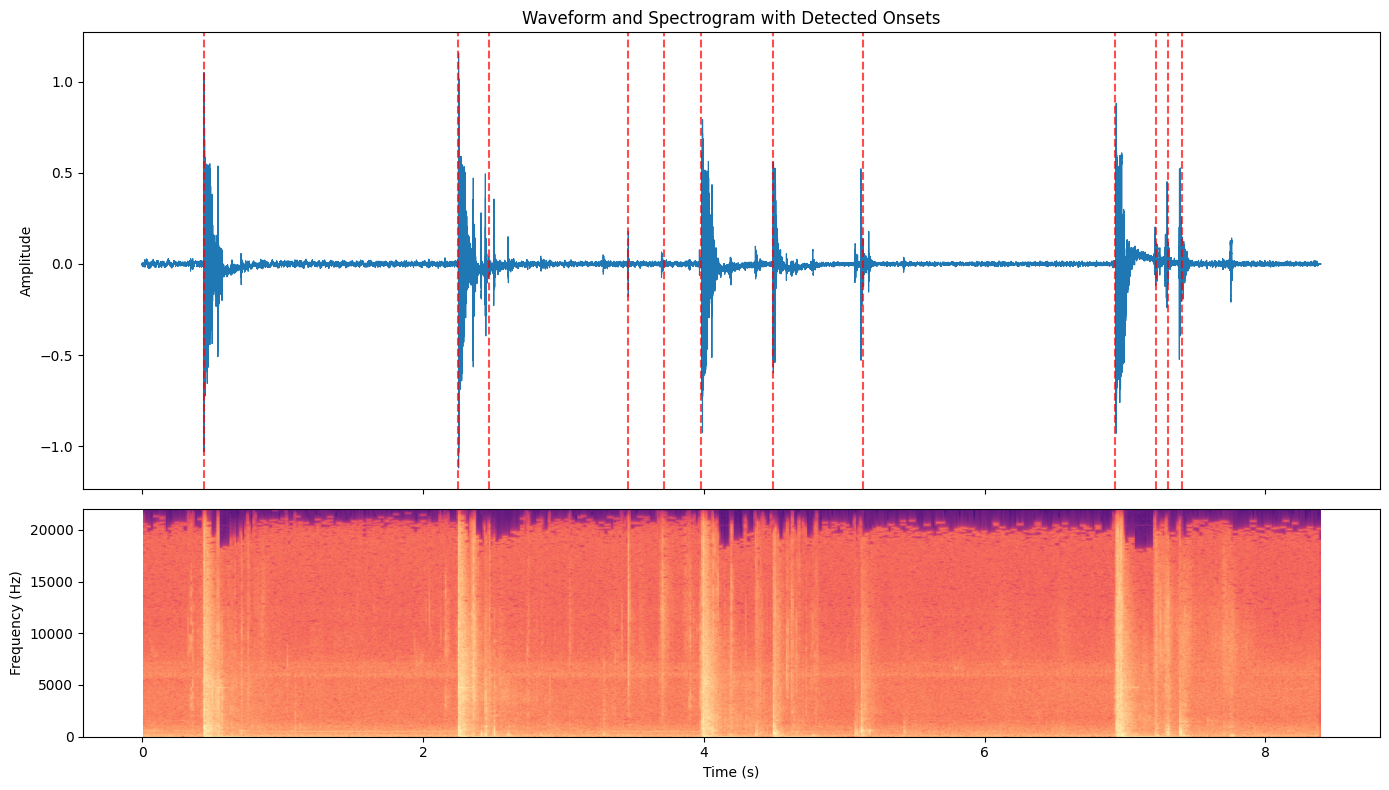

In [76]:
inspect_sound("../data/meta", 85_534)

In [37]:
!ls ../data/audio

105344_14771-hq.ogg    382585_313780-hq.ogg    628635_9129912-hq.ogg
114249_2022196-hq.ogg  384411_5407590-hq.ogg   636957_5479102-hq.ogg
119114_1550701-hq.ogg  386223_1655965-hq.ogg   638640_433684-hq.ogg
119650_2085904-hq.ogg  389464_6060491-hq.ogg   641009_13325778-hq.ogg
131469_2337088-hq.ogg  389672_7158173-hq.ogg   641145_13071295-hq.ogg
13278_32468-hq.ogg     406230_6068748-hq.ogg   650593_7965922-hq.ogg
149732_1031833-hq.ogg  414461_1738686-hq.ogg   652638_10888079-hq.ogg
152533_2289019-hq.ogg  418555_8333239-hq.ogg   66113_877451-hq.ogg
16743_26950-hq.ogg     419928_8373708-hq.ogg   663470_14283090-hq.ogg
16744_26950-hq.ogg     421928_8090574-hq.ogg   669467_1106446-hq.ogg
17624_6448-hq.ogg      421929_8090574-hq.ogg   674609_9243191-hq.ogg
190698_1469582-hq.ogg  429713_7872621-hq.ogg   675777_2524442-hq.ogg
242044_2023214-hq.ogg  434205_2780734-hq.ogg   677016_14745363-hq.ogg
244637_4478454-hq.ogg  434402_3045606-hq.ogg   681774_14331083-hq.ogg
245225_1648170-hq.ogg  444372_4

In [79]:
analyze_repetitiveness("../data/audio/85534_1275441-hq.ogg", window_ms=200)

--- Analyzing: 85534_1275441-hq.ogg ---
Total raw onsets detected: 12
Onsets passing LAT filter (< 0.08s): 5
Percussive onset MFCCs shape (5, 12)
Dist matrix shape: (5, 5)
--> Found repeating event! Repetitions count: 5



,time,lat,crest,mfcc,cluster
0,2.252336,-1.850648,5.614538,"[56.731068, 28.405933, 41.249184, -11.891359, ...",0
1,3.459773,-1.074129,22.195759,"[104.66297, 54.038128, 31.014591, -17.92845, 9...",0
2,3.715193,-0.816359,5.363480,"[95.72225, 55.167988, 32.940495, -6.1019354, 2...",0
3,5.131610,-1.382225,8.624388,"[108.06989, 36.575405, 33.350586, -11.998195, ...",0
4,7.221406,-0.787408,6.751866,"[104.121864, 47.10927, 13.354158, 4.538957, 7....",0


In [102]:
def inspect_sound(meta_dir, sound_id, method="hfc"):
    """
    Finds a sound, runs your existing analyze_repetitiveness function,
    and plots all onsets (Red) with Repetitive ones highlighted (Green).
    """
    for csv_path in glob.glob(os.path.join(meta_dir, "dataset_*.csv")):
        df = pd.read_csv(csv_path)
        match = df[df["sound_id"] == sound_id]
        
        if not match.empty:
            row = match.iloc[0]
            local_path = row["local_path"]
            
            # 1. Get raw onsets using your detection helper
            audio, onset_times = detect_onsets(local_path, method=method)
            
            # 2. Call your EXACT existing function to get the 'repetitive' mask
            # I'm assuming analyze_repetitiveness returns (is_repetitive, onsets, stats) 
            # or similar based on our previous workflow.
            is_repetitive, _, _ = analyze_repetitiveness(onset_times)
            
            print(f"--- Sound ID: {sound_id} ---")
            print(f"File: {os.path.basename(local_path)}")
            print(f"Method: {method} | Detected: {len(onset_times)} | Repetitive: {sum(is_repetitive)}")

            # 3. Plotting
            sample_rate = 44100
            time_axis = np.arange(len(audio)) / sample_rate
            
            fig, ax = plt.subplots(figsize=(14, 4))
            ax.plot(time_axis, audio, color='gray', alpha=0.4, linewidth=0.8)
            
            # Loop through onsets and their "is_repetitive" status
            for t, repetitive in zip(onset_times, is_repetitive):
                if repetitive:
                    # Thick Green line for sounds flagged by your algorithm
                    ax.axvline(t, color="green", linestyle="-", linewidth=2.5, alpha=0.8)
                else:
                    # Thin Red line for general onsets
                    ax.axvline(t, color="red", linestyle="--", linewidth=1, alpha=0.6)
            
            ax.set_title(f"Repetition Inspection: {row['name']}")
            ax.set_ylabel("Amplitude")
            ax.set_xlabel("Time (s)")
            
            # Custom legend
            from matplotlib.lines import Line2D
            custom_lines = [Line2D([0], [0], color='red', lw=1, linestyle='--'),
                            Line2D([0], [0], color='green', lw=2.5)]
            ax.legend(custom_lines, ['Other Onsets', 'Repetitive Pattern'])

            plt.tight_layout()
            plt.show()
            
            display(Audio(local_path))
            return

    print(f"Sound ID {sound_id} not found.")

In [112]:
ids = print_ids_for_query("../data/meta", "popcorn")

--- POPCORN (20 sounds) ---
25419
261595
264168
264169
271391
324708
325660
334494
363146
493255
541538
575722
614586
636957
641145
652638
663470
677016
781106
807764


--- Sound ID: 636957 ---
Total Onsets: 7 (Red)
Repetitive Onsets: 5 (Green)


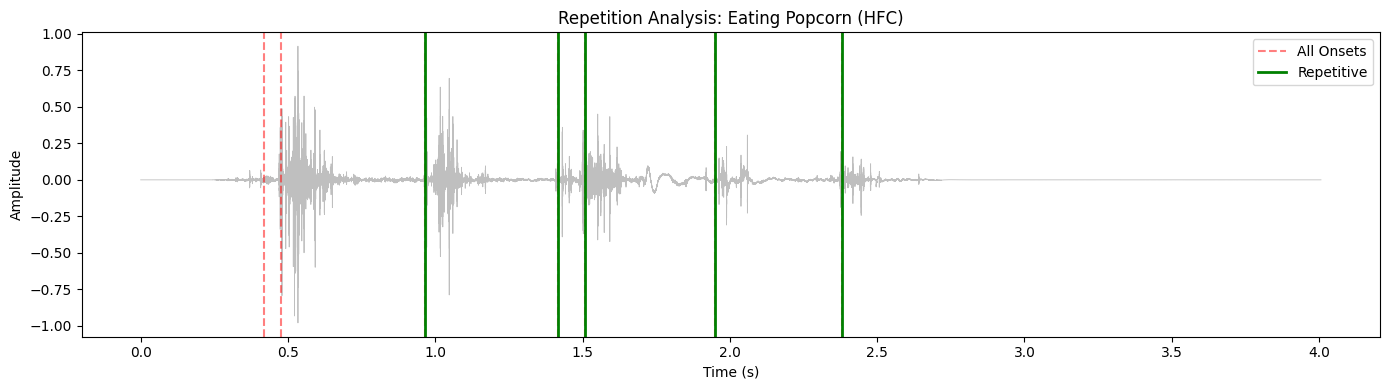

In [119]:
inspect_sound_with_repetition(META_DIR,636957, method="hfc")

---

### Analyze repetitiveness

In [101]:
import sklearn
import essentia.standard as es
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

def analyze_repetitiveness(audio_path, sr=44100, window_ms=150, lat_threshold=0.08, eps=0.15):
    """
    Analyzes an audio file for repetitive percussive events.
    
    1. Detects onsets.
    2. Calculates LogAttackTime and MFCCs for the 150ms window after each onset.
    3. Filters out sounds with slow attacks (non-percussive).
    4. Clusters the remaining MFCC signatures to find repetitions.
    """
    print(f"--- Analyzing: {audio_path.split('/')[-1]} ---")
    
    # 1. load audio and detect onsets
    audio = es.MonoLoader(filename=audio_path, sampleRate=sr)()
    od_method = es.OnsetDetection(method='hfc')
    w = es.Windowing(type='hann')
    fft = es.FFT()
    c2p = es.CartesianToPolar()
    
    pool = essentia.Pool()
    for frame in es.FrameGenerator(audio, frameSize=1024, hopSize=512):
        mag, phase = c2p(fft(w(frame)))
        pool.add('odf.method', od_method(mag, phase))

    onsets = es.Onsets()(essentia.array([pool['odf.method']]), [1])
    print(f"Total raw onsets detected: {len(onsets)}")
    
    if len(onsets) == 0:
        return None
    
    # 2. extract Features per onset
    window_samples = int((window_ms / 1000.0) * sr)
    
    # Essentia extractors
    envelope = es.Envelope()
    log_attack = es.LogAttackTime()
    spectrum = es.Spectrum()
    mfcc = es.MFCC(inputSize=513)
    
    features = []
    last_onset_time = -1.0

    min_ioi = 0.25  # adjustable param
    
    for onset in onsets:
        # if this onset is too close the last valid one, skip it
        # (avoids picking up echoes of the sound events)
        if (onset - last_onset_time) < min_ioi:
            continue
        
        start_idx = int(onset * sr)
        end_idx = min(start_idx + window_samples, len(audio))
        segment = audio[start_idx:end_idx]
        
        # skip if too close to the end of the file
        if len(segment) < 1024:
            continue


        # Peak amplitude divided by RMS (average) amplitude
        peak_amp = np.max(np.abs(segment))
        rms_amp = np.sqrt(np.mean(segment**2)) + 1e-9 
        crest_factor = peak_amp / rms_amp

        # skip sounds that are not "peaky"
        if crest_factor < 5.0:  # adjustable parameter
            continue
            
        # LogAttackTime algorithm expects the envelope of the signal
        env = envelope(segment)
        try:
            # returns: (logAttackTime, attackStart, attackStop)
            lat = log_attack(env)[0] 
        except:
            lat = 1.0 # default high value if it fails
            
        # sound event similarity: MFCC;
        # - this method of measuring sound event similarity could be considered
        #   a variable parameter; this block would need to be rewritten in a more
        #   more modular fashion
        segment_mfccs = []
        for frame in es.FrameGenerator(segment, frameSize=1024, hopSize=512, startFromZero=True):
            _, mfcc_coeffs = mfcc(spectrum(w(frame)))
            
            # exclude the 0th coefficient (energy) so we cluster by timbre, not volume
            segment_mfccs.append(mfcc_coeffs[1:]) 
            
        mean_mfcc = np.mean(segment_mfccs, axis=0)

        last_onset_time = onset
        
        features.append({
            'time': onset,
            'lat': lat,
            'crest': crest_factor,
            'mfcc': mean_mfcc
        })
        
    df = pd.DataFrame(features)
    
    # 3. filter by Log Attack Time
    # - keep only sharp, fast attacks
    percussive_df = df[df['lat'] < lat_threshold].copy()
    print(f"Onsets passing LAT filter (< {lat_threshold}s): {len(percussive_df)}")
    
    if len(percussive_df) < 2:
        print("Not enough percussive events to cluster.\n")
        return None
        
    # 4. clustering (pairwise similarity)
    # - convert list of arrays to 2D numpy array
    X_mfcc = np.vstack(percussive_df['mfcc'].values)
    print("Percussive onset MFCCs shape", X_mfcc.shape)
    
    # compute cosine distance (great for spectral features)
    dist_matrix = pairwise_distances(X_mfcc, metric='cosine')

    print("Dist matrix shape:", dist_matrix.shape)
    
    # DBSCAN: groups events that are similar. eps is the distance threshold.
    clusterer = DBSCAN(eps=eps, min_samples=3, metric='precomputed')
    percussive_df['cluster'] = clusterer.fit_predict(dist_matrix)
    
    # count repetitions (excluding noise, which DBSCAN labels as -1)
    clusters = percussive_df[percussive_df['cluster'] != -1]
    
    if not clusters.empty:
        largest_cluster = clusters['cluster'].value_counts().idxmax()
        rep_count = len(clusters[clusters['cluster'] == largest_cluster])
        print(f"--> Found repeating event! Repetitions count: {rep_count}\n")
    else:
        print("--> No repeating clusters found.\n")
        
    return percussive_df

# --- test on "nice" samples, positive and negative ---
wood_file = "../data/audio/766242_15773983-hq.ogg"  
water_file = "../data/audio/384411_5407590-hq.ogg" 

print("TEST 1: CHOPPING WOOD")
df_wood = analyze_repetitiveness(wood_file)

print("TEST 2: RUNNING WATER")
df_water = analyze_repetitiveness(water_file)

TEST 1: CHOPPING WOOD
--- Analyzing: 766242_15773983-hq.ogg ---
Total raw onsets detected: 6
Onsets passing LAT filter (< 0.08s): 4
Percussive onset MFCCs shape (4, 12)
Dist matrix shape: (4, 4)
--> Found repeating event! Repetitions count: 4

TEST 2: RUNNING WATER
--- Analyzing: 384411_5407590-hq.ogg ---
Total raw onsets detected: 29
Onsets passing LAT filter (< 0.08s): 4
Percussive onset MFCCs shape (4, 12)
Dist matrix shape: (4, 4)
--> No repeating clusters found.



In [80]:
df_wood.iloc[1]

time                                                2.124626
lat                                                -2.401401
crest                                              12.721688
mfcc       [102.17635, 8.997907, 13.609073, 13.488162, 23...
cluster                                                    0
Name: 1, dtype: object

In [75]:
print(f"Log Attack Time for this wood chop: {df_wood['lat'].iloc[0]}")

Log Attack Time for this wood chop: -2.173146963119507


In [40]:
!ls -lt ../data/audio

total 16344
-rw-r--r-- 1 root root 118672 May  1 13:19 560237_12522432-hq.ogg
-rw-r--r-- 1 root root 143805 May  1 13:19 16744_26950-hq.ogg
-rw-r--r-- 1 root root 204555 May  1 13:19 832868_18115820-hq.ogg
-rw-r--r-- 1 root root 146336 May  1 13:19 389672_7158173-hq.ogg
-rw-r--r-- 1 root root 138272 May  1 13:19 389464_6060491-hq.ogg
-rw-r--r-- 1 root root 406622 May  1 13:19 382585_313780-hq.ogg
-rw-r--r-- 1 root root 104316 May  1 13:19 119114_1550701-hq.ogg
-rw-r--r-- 1 root root  46650 May  1 13:19 827443_17908330-hq.ogg
-rw-r--r-- 1 root root 131921 May  1 13:19 384411_5407590-hq.ogg
-rw-r--r-- 1 root root  83310 May  1 13:19 816996_17552599-hq.ogg
-rw-r--r-- 1 root root 168144 May  1 13:19 406230_6068748-hq.ogg
-rw-r--r-- 1 root root 190055 May  1 13:19 347407_6325453-hq.ogg
-rw-r--r-- 1 root root 119743 May  1 13:19 16743_26950-hq.ogg
-rw-r--r-- 1 root root 165502 May  1 13:19 131469_2337088-hq.ogg
-rw-r--r-- 1 root root  42759 May  1 13:19 34992_268901-hq.ogg
-rw-r--r-- 1 root 